In [1]:
import numpy as np
import xarray as xr
import glob
import dask
from scipy.stats import lognorm,iqr
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

In [2]:
basecase_ds = xr.open_dataset('/home/chandras/mosaic-paper/sensitivityanalysis/dailypath/basecase_dailypath.nc')
bulkmsa = glob.glob('/home/chandras/mosaic-paper/sensitivityanalysis/dailypath/bulkmsa_dailypath.nc')
so4nucl = glob.glob('/home/chandras/mosaic-paper/sensitivityanalysis/dailypath/so4nucl_dailypath.nc')
dmshigh = glob.glob('/home/chandras/mosaic-paper/sensitivityanalysis/dailypath/dmshigh_dailypath.nc')
dmslow = glob.glob('/home/chandras/mosaic-paper/sensitivityanalysis/dailypath/dmslow_dailypath.nc')
msaelvoc = glob.glob('/home/chandras/mosaic-paper/sensitivityanalysis/dailypath/msaelvoc_dailypath.nc')
msasvoc = glob.glob('/home/chandras/mosaic-paper/sensitivityanalysis/dailypath/msasvoc_dailypath.nc')
nuclhigh = glob.glob('/home/chandras/mosaic-paper/sensitivityanalysis/dailypath/nuclhigh_dailypath.nc')
nucllow = glob.glob('/home/chandras/mosaic-paper/sensitivityanalysis/dailypath/nucllow_dailypath.nc')
sshigh = glob.glob('/home/chandras/mosaic-paper/sensitivityanalysis/dailypath/sshigh_dailypath.nc')
sslow = glob.glob('/home/chandras/mosaic-paper/sensitivityanalysis/dailypath/sslow_dailypath.nc')

/home/chandras/anaconda3/envs/ccnproj/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gini' loading failed:
module 'numpy' has no attribute 'cumproduct'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [3]:
def month_avg(filename):
    ds = xr.open_dataset(filename[0])
    ds = ds.sel(time = slice('01-01-2019',None))
    ds = ds.resample(time = '1ME').median()
    
    '''ds = ds.mean(dim = 'ncells')
    for i in range(1,12):
        temp = xr.open_dataset(filename[i])
        temp  = temp.mean(dim = 'ncells')
        ds = xr.combine_by_coords([ds,temp])'''
    return(ds)
    

In [4]:
#basecase_ds = xr.open_dataset('/home/chandras/mosaic-paper/mosaic_pathvals_surface/req_val_files_basecase_pathvals_surface.nc')
#basecase_ds = basecase_ds.groupby('time.month')
bulkmsa_ds = month_avg(bulkmsa)
basecase_nonucl_ds = month_avg(so4nucl)
dmshigh_ds = month_avg(dmshigh)
dmslow_ds = month_avg(dmslow)
msaelvoc_ds = month_avg(msaelvoc)
msasvoc_ds = month_avg(msasvoc)
nuclhigh_ds = month_avg(nuclhigh)
nucllow_ds = month_avg(nucllow)
sshigh_ds = month_avg(sshigh)
sslow_ds = month_avg(sslow)

In [5]:
cmap = mpl.colormaps['hsv']
color = ['#EE7733','#0077BB','#33BBEE','#EE3377','#CC3311','#009988']

In [6]:
def monthly_file(filename,skip_line_no,pollution,var):
    df = pd.read_csv(filename,skiprows=skip_line_no,sep='\t')
    df['Date/Time'] = pd.to_datetime(df['Date/Time'])
    df= df.where(df['Date/Time'] < '2020-10-01') 
    df = df.drop(['Event'],axis = 1)
    df = df[df[pollution] != 1]
    df = df.resample('1D',on = 'Date/Time').mean()
    df = df.dropna()
    #df.set_index('Date/Time', inplace=True)
    #df = df.groupby(pd.Grouper(key='Date/Time', freq='M',group_keys = True))
    return(df)

In [7]:
mosaic_obs= monthly_file('../cpc3025_pollution_flag_1min(1).tab',43,'Flag','CP_conc [#/cm**3]')

In [8]:
#ds = basecase_ds.groupby('time.month')
list = [10,11,12,1,2,3,4,5,6,7,8,9]
#for i in range(12):
#    plt.violinplot(ds[list[i]].conccn,positions = [i-0.5])

In [9]:
mosaic_obs = mosaic_obs.reset_index()

In [10]:
mosaic_obs.where(mosaic_obs['Date/Time'].dt.month == 1).dropna()

,Date/Time,Latitude,Longitude,CP_conc [#/cm**3],Flag
76,2020-01-01,86.688855,117.944030,219.044789,0.0
77,2020-01-02,86.839971,116.322124,510.840276,0.0
78,2020-01-03,86.916484,115.683674,209.276341,0.0
79,2020-01-04,87.005989,115.406199,177.316467,0.0
80,2020-01-05,87.069476,115.321569,129.342812,0.0
81,2020-01-06,87.103086,115.159197,154.408707,0.0
82,2020-01-07,87.118390,115.005855,162.723904,0.0
83,2020-01-08,87.115208,115.136402,208.636720,0.0
84,2020-01-11,87.236291,110.780323,83.000799,0.0
85,2020-01-12,87.268979,109.673635,94.592070,0.0


In [11]:
timeline = np.arange(1,25,2)


obs_ds = [mosaic_obs['CP_conc [#/cm**3]'].where(mosaic_obs['Date/Time'].dt.month == list[i//2]).dropna() for i in timeline]
obs_median = [np.median(mosaic_obs['CP_conc [#/cm**3]'].where(mosaic_obs['Date/Time'].dt.month == list[i//2]).dropna()) for i in timeline]
tm5_ds =  [basecase_ds.groupby('time.month')[i]['conccn'].to_numpy() for i in list]
tm5_median = [np.median(basecase_ds.groupby('time.month')[i]['conccn'].to_numpy()) for i in list]

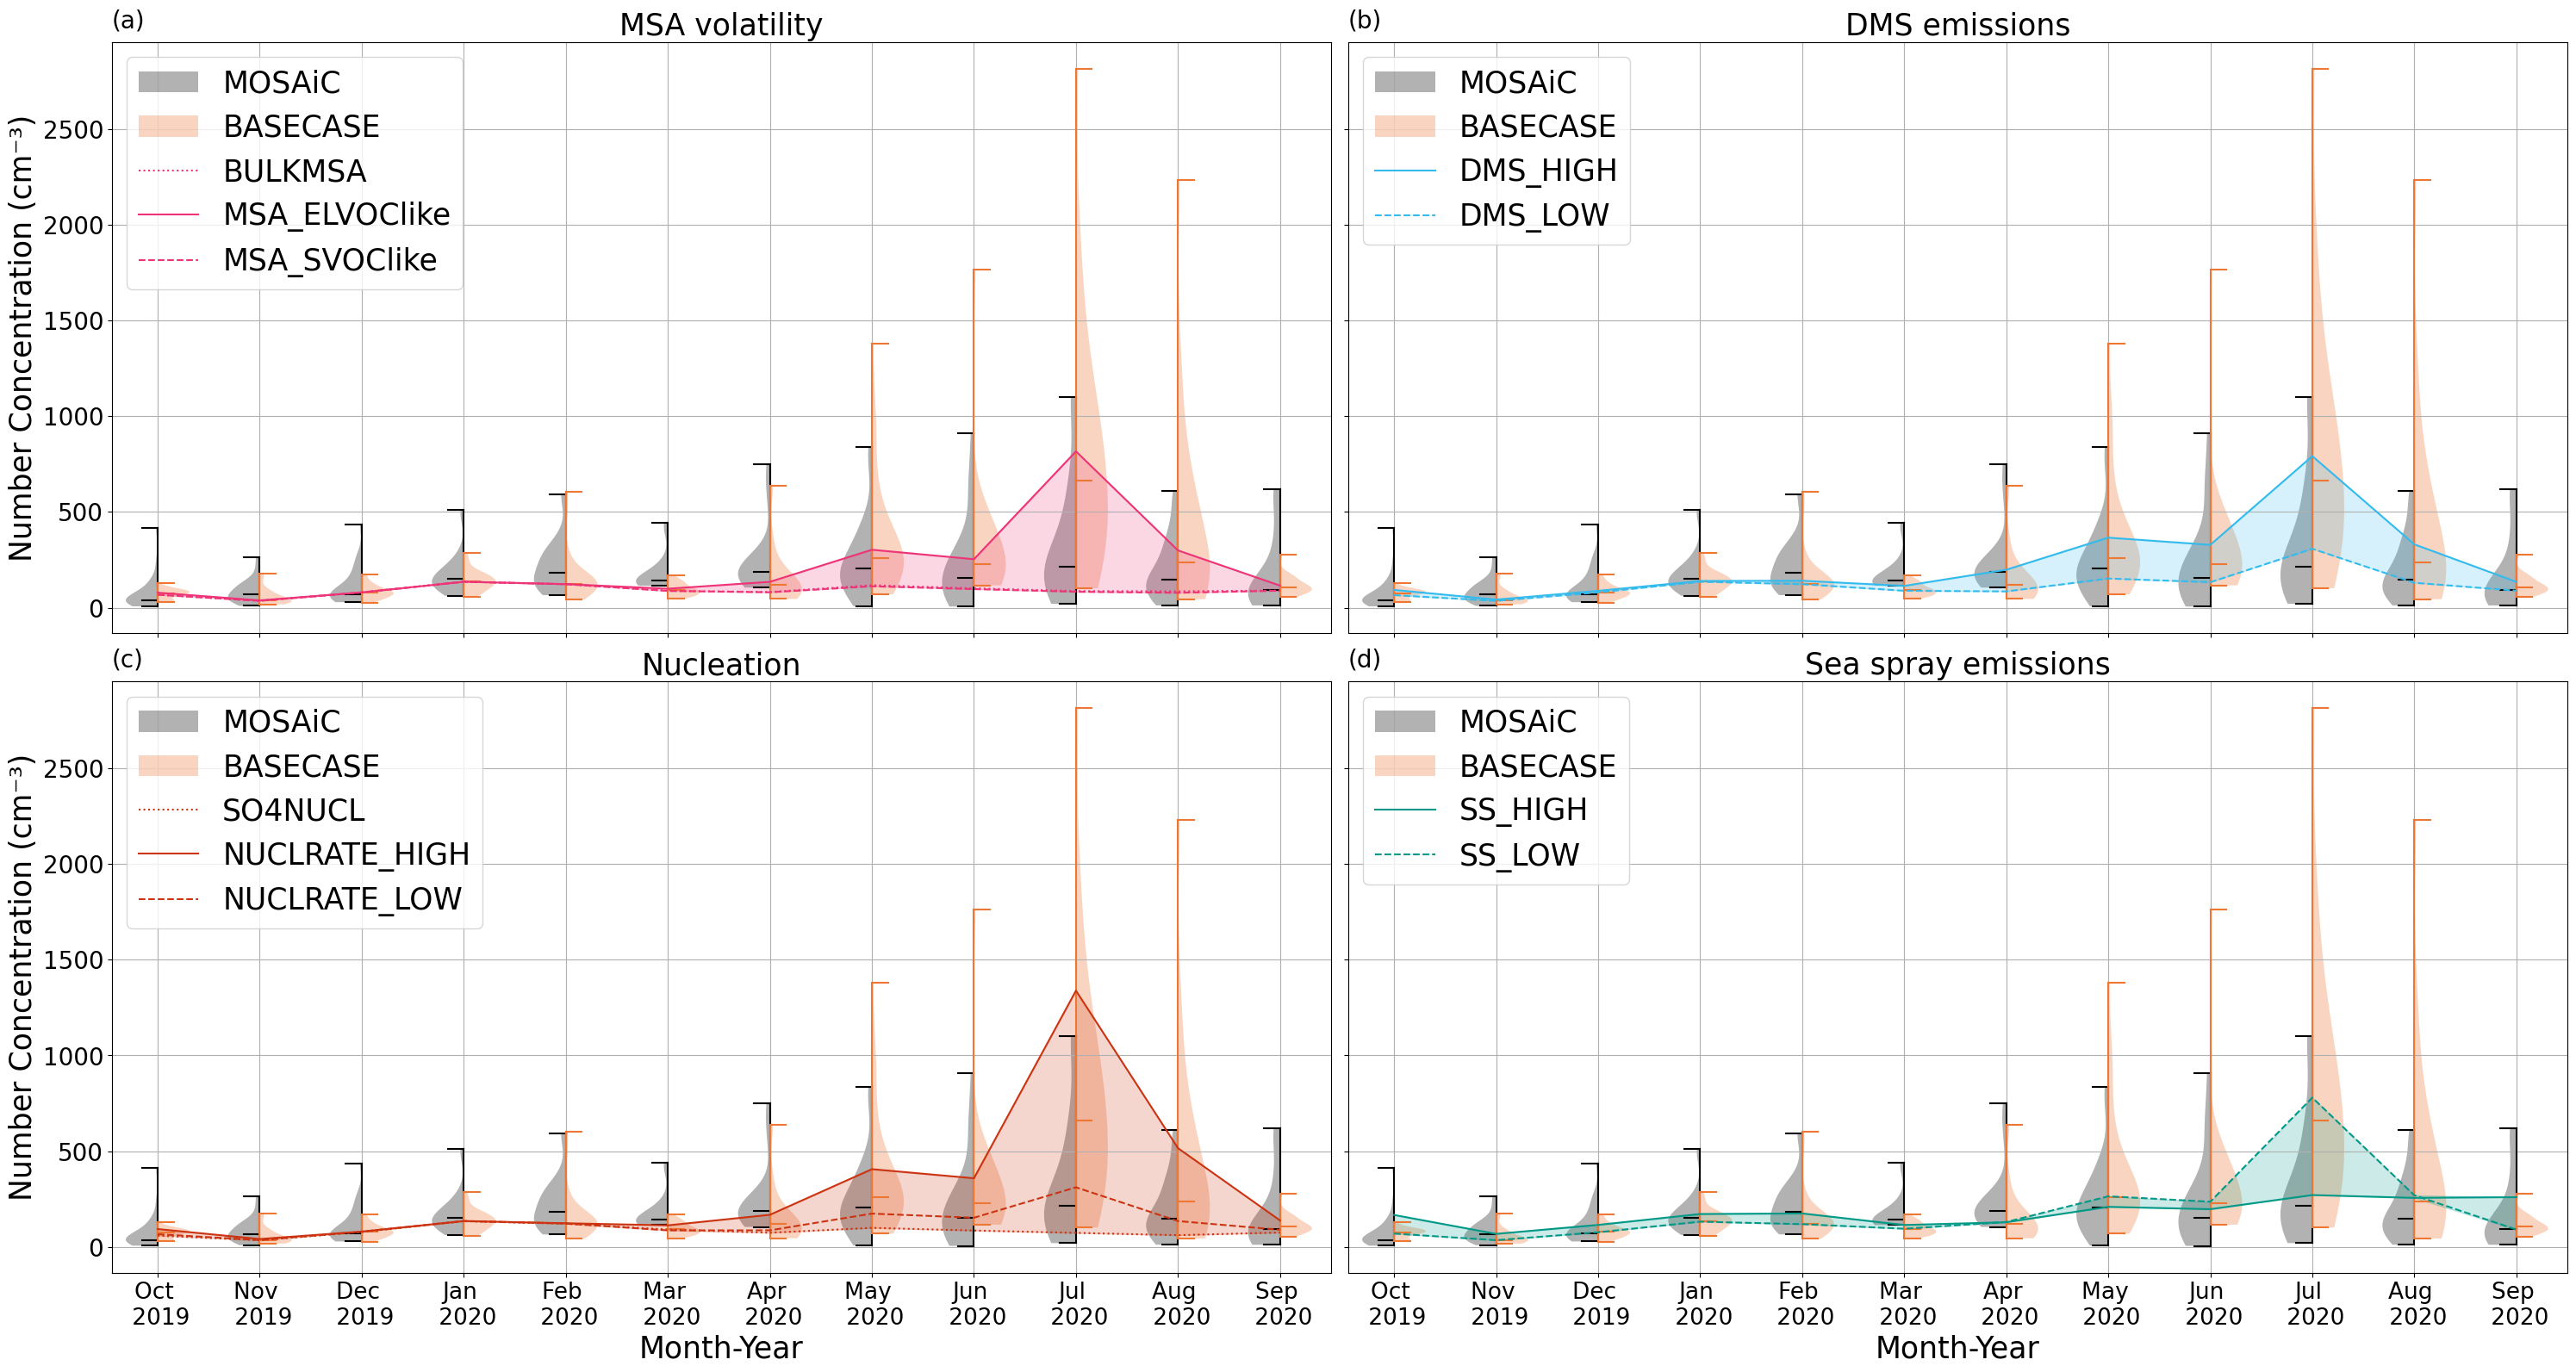

In [13]:
timeline = np.arange(1,25,2)
stair = np.arange(1.0,25.0,4.0)
fig,ax = plt.subplots(2,2,figsize = (30,16),sharex = True,sharey= True)

## MSA volatility
ax[0,0].set_title('MSA volatility',fontsize = 25)
ax[0,0].text(0, 1.025,'(a)',transform=ax[0,0].transAxes,size = 20)
obs = ax[0,0].violinplot(obs_ds,positions = timeline,showmedians=True,side = 'low',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
tm5 = ax[0,0].violinplot(tm5_ds,positions = timeline,showmedians=True,side = 'high',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
for pc in obs['bodies']:
    pc.set_facecolor('k')
for pc in tm5['bodies']:
    pc.set_facecolor(color[0])
obs['cmins'].set_color('k')
obs['cmaxes'].set_color('k')
obs['cbars'].set_color('k')
obs['cmedians'].set_color('k')
tm5['cmins'].set_color(color[0])
tm5['cmaxes'].set_color(color[0])
tm5['cbars'].set_color(color[0])
tm5['cmedians'].set_color(color[0])
obs['bodies'][0].set_label('MOSAiC')
tm5['bodies'][0].set_label('BASECASE')
bx2 = ax[0,0].plot(timeline,bulkmsa_ds.conccn, color = color[3],linestyle = 'dotted',label = 'BULKMSA')
bx6 = ax[0,0].plot(timeline,msaelvoc_ds.conccn,color = color[3],label = 'MSA_ELVOClike')
bx7 = ax[0,0].plot(timeline,msasvoc_ds.conccn,color = color[3],linestyle = '--',label = 'MSA_SVOClike')
#print(np.array([bulkmsa_ds.conccn,msaelvoc_ds.conccn,msasvoc_ds.conccn]).min(axis = 0))
shades = ax[0,0].fill_between(timeline,np.array([bulkmsa_ds.conccn,msaelvoc_ds.conccn,msasvoc_ds.conccn]).min(axis = 0),np.array([bulkmsa_ds.conccn,msaelvoc_ds.conccn,msasvoc_ds.conccn]).max(axis = 0),color = color[3],alpha = 0.2)


ax[0,0].set_xticks(ticks = timeline,labels = [ '10-2019', '11-2019', '12-2019', '01-2020', '02-2020', '03-2020', '04-2020', '05-2020', '06-2020', '07-2020', '08-2020', '09-2020'],fontsize = 25)
#for i in range(1,25,4):
#    plt.axvspan(i-1,i+1,color = '0.2', alpha=0.1, lw=0)
ax[0,0].legend(loc = 'upper left',fontsize = 25)
#ax[0,0].set_xlabel('Month-Year',fontsize = 25)
ax[0,0].set_ylabel('Number Concentration (cm⁻³)',fontsize = 25)
ax[0,0].tick_params(axis = 'y',labelsize = 20)
ax[0,0].set_xlim(0.1,24)
#ax[0,0].set_ylim(0,2000)
## DMS emissions
ax[0,1].set_title('DMS emissions',fontsize = 25)
ax[0,1].text(0, 1.025,'(b)',transform=ax[0,1].transAxes,size = 20)
obs = ax[0,1].violinplot(obs_ds,positions = timeline,showmedians=True,side = 'low',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
tm5 = ax[0,1].violinplot(tm5_ds,positions = timeline,showmedians=True,side = 'high',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
for pc in obs['bodies']:
    pc.set_facecolor('k')
for pc in tm5['bodies']:
    pc.set_facecolor(color[0])
obs['cmins'].set_color('k')
obs['cmaxes'].set_color('k')
obs['cbars'].set_color('k')
obs['cmedians'].set_color('k')
tm5['cmins'].set_color(color[0])
tm5['cmaxes'].set_color(color[0])
tm5['cbars'].set_color(color[0])
tm5['cmedians'].set_color(color[0])
obs['bodies'][0].set_label('MOSAiC')
tm5['bodies'][0].set_label('BASECASE')
bx4 = ax[0,1].plot(timeline,dmshigh_ds.conccn,color = color[2],label = 'DMS_HIGH')
bx5 = ax[0,1].plot(timeline,dmslow_ds.conccn,color = color[2],linestyle = '--',label = 'DMS_LOW')
ax[0,1].fill_between(timeline,np.array([dmshigh_ds.conccn,dmslow_ds.conccn]).min(axis = 0), np.array([dmshigh_ds.conccn,dmslow_ds.conccn]).max(axis = 0),color = color[2],alpha = 0.2)
ax[0,1].set_xticks(ticks = timeline,labels = [ '10-2019', '11-2019', '12-2019', '01-2020', '02-2020', '03-2020', '04-2020', '05-2020', '06-2020', '07-2020', '08-2020', '09-2020'],fontsize = 25)
#for i in range(1,25,4):
#    plt.axvspan(i-1,i+1,color = '0.2', alpha=0.1, lw=0)
ax[0,1].legend(loc = 'upper left',fontsize = 25)
#ax[0,1].set_xlabel('Month-Year',fontsize = 25)
#ax[0,1].set_ylabel('Number Concentration (cm⁻³)',fontsize = 25)
ax[0,1].tick_params(axis = 'y',labelsize = 20)
ax[0,1].set_xlim(0.1,24)

## NUCLEATION RATE

ax[1,0].set_title('Nucleation',fontsize = 25)
ax[1,0].text(0, 1.025,'(c)',transform=ax[1,0].transAxes,size = 20)
obs = ax[1,0].violinplot(obs_ds,positions = timeline,showmedians=True,side = 'low',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
tm5 = ax[1,0].violinplot(tm5_ds,positions = timeline,showmedians=True,side = 'high',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
for pc in obs['bodies']:
    pc.set_facecolor('k')
for pc in tm5['bodies']:
    pc.set_facecolor(color[0])
obs['cmins'].set_color('k')
obs['cmaxes'].set_color('k')
obs['cbars'].set_color('k')
obs['cmedians'].set_color('k')
tm5['cmins'].set_color(color[0])
tm5['cmaxes'].set_color(color[0])
tm5['cbars'].set_color(color[0])
tm5['cmedians'].set_color(color[0])
obs['bodies'][0].set_label('MOSAiC')
tm5['bodies'][0].set_label('BASECASE')
bx3 = ax[1,0].plot(timeline,basecase_nonucl_ds.conccn,color = color[4],label = 'SO4NUCL',linestyle = 'dotted')
bx4 = ax[1,0].plot(timeline,nuclhigh_ds.conccn,color = color[4],label = 'NUCLRATE_HIGH')
bx5 = ax[1,0].plot(timeline,nucllow_ds.conccn,color = color[4],linestyle = '--',label = 'NUCLRATE_LOW')
ax[1,0].fill_between(timeline,np.array([nuclhigh_ds.conccn,nucllow_ds.conccn,basecase_nonucl_ds.conccn]).min(axis = 0), np.array([nuclhigh_ds.conccn,nucllow_ds.conccn,basecase_nonucl_ds.conccn]).max(axis = 0),color = color[4],alpha = 0.2)
ax[1,0].set_xticks(ticks = timeline,labels = [ '10-2019', '11-2019', '12-2019', '01-2020', '02-2020', '03-2020', '04-2020', '05-2020', '06-2020', '07-2020', '08-2020', '09-2020'],fontsize = 19)
#for i in range(1,25,4):
#    plt.axvspan(i-1,i+1,color = '0.2', alpha=0.1, lw=0)
ax[1,0].legend(loc = 'upper left',fontsize = 25)
ax[1,0].set_xlabel('Month-Year',fontsize = 25)
ax[1,0].tick_params(axis = 'y',labelsize = 20)
ax[1,0].set_ylabel('Number Concentration (cm⁻³)',fontsize = 25)
ax[1,0].set_xlim(0.1,24)

## SEA SALT EMISSIONS
ax[1,1].set_title('Sea spray emissions', fontsize = 25)
ax[1,1].text(0, 1.025,'(d)',transform=ax[1,1].transAxes,size = 20)
obs = ax[1,1].violinplot(obs_ds,positions = timeline,showmedians=True,side = 'low',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
tm5 = ax[1,1].violinplot(tm5_ds,positions = timeline,showmedians=True,side = 'high',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
for pc in obs['bodies']:
    pc.set_facecolor('k')
for pc in tm5['bodies']:
    pc.set_facecolor(color[0])
obs['cmins'].set_color('k')
obs['cmaxes'].set_color('k')
obs['cbars'].set_color('k')
obs['cmedians'].set_color('k')
tm5['cmins'].set_color(color[0])
tm5['cmaxes'].set_color(color[0])
tm5['cbars'].set_color(color[0])
tm5['cmedians'].set_color(color[0])
obs['bodies'][0].set_label('MOSAiC')
tm5['bodies'][0].set_label('BASECASE')
bx10 = ax[1,1].plot(timeline,sshigh_ds.conccn,color = color[5],label ='SS_HIGH')
bx11 = ax[1,1].plot(timeline,sslow_ds.conccn,color = color[5],linestyle = '--',label ='SS_LOW')
ax[1,1].fill_between(timeline,np.array([sshigh_ds.conccn,sslow_ds.conccn]).min(axis = 0), np.array([sshigh_ds.conccn,sslow_ds.conccn]).max(axis = 0),color = color[5],alpha = 0.2)
ax[1,1].set_xticks(ticks = timeline,labels = [ 'Oct \n 2019', 'Nov \n 2019', 'Dec \n 2019', 'Jan \n 2020', 'Feb \n 2020', 'Mar \n 2020', 'Apr \n 2020', 'May \n 2020', 'Jun \n 2020', 'Jul \n 2020', 'Aug \n 2020', 'Sep \n 2020'],fontsize = 19)
#    plt.axvspan(i-1,i+1,color = '0.2', alpha=0.1, lw=0)
ax[1,1].legend(loc = 'upper left',fontsize = 25)
ax[1,1].set_xlabel('Month-Year',fontsize = 25)
#ax[1,1].set_ylabel('Number Concentration (cm⁻³)',fontsize = 25)
ax[1,1].set_xlim(0.1,24)

'''
bx2 = ax.plot(timeline,bulkmsa_ds.conccn, color = color[1],label = 'BULKMSA')
bx3 = ax.plot(timeline,basecase_nonucl_ds.conccn,color = color[1],label = 'SO4NUCL',linestyle = '--')
bx4 = ax.plot(timeline,dmshigh_ds.conccn,color = color[2],label = 'DMS_HIGH')
bx5 = ax.plot(timeline,dmslow_ds.conccn,color = color[2],linestyle = '--',label = 'DMS_LOW')
bx6 = ax.plot(timeline,msaelvoc_ds.conccn,color = color[3],label = 'MSA_ELVOClike')
bx7 = ax.plot(timeline,msasvoc_ds.conccn,color = color[3],linestyle = '--',label = 'MSA_SVOClike')
bx8 = ax.plot(timeline,nuclhigh_ds.conccn,color = color[4],label = 'NUCL_HIGH')
bx9 = ax.plot(timeline,nucllow_ds.conccn,color = color[4],linestyle='--',label = 'NUCL_LOW')
bx10 = ax.plot(timeline,sshigh_ds.conccn,color = color[5],label ='SS_HIGH')
bx11 = ax.plot(timeline,sslow_ds.conccn,color = color[5],linestyle = '--',label ='SS_LOW')
'''
plt.tight_layout()
for i in range(2):
    for j in range(2):
        ax[i,j].grid()
#plt.show()

#ax.set_ylim(top= 24.25)
#ax.set_yscale('log')
#print(bx1)
plt.savefig('../figures/conccn_monthlyavg_tiles1.png',dpi = 300)

In [14]:
mosaic_obs_ccn= monthly_file('../CCNC_SS_0.20.tab',38,'Flag pollution','CP_conc [#/cm**3]')
mosaic_obs_ccn = mosaic_obs_ccn.reset_index()

In [15]:
timeline = np.arange(1,25,2)


obs_ds = [mosaic_obs_ccn['CP_conc [#/cm**3]'].where(mosaic_obs_ccn['Date/Time'].dt.month == list[i//2]).dropna() for i in timeline[:8]]
obs_median = [np.median(mosaic_obs_ccn['CP_conc [#/cm**3]'].where(mosaic_obs_ccn['Date/Time'].dt.month == list[i//2]).dropna()) for i in timeline[:8]]
tm5_ds =  [basecase_ds.groupby('time.month')[i]['CCN0.20'].to_numpy() for i in list]
tm5_median = [np.median(basecase_ds.groupby('time.month')[i]['CCN0.20'].to_numpy()) for i in list]


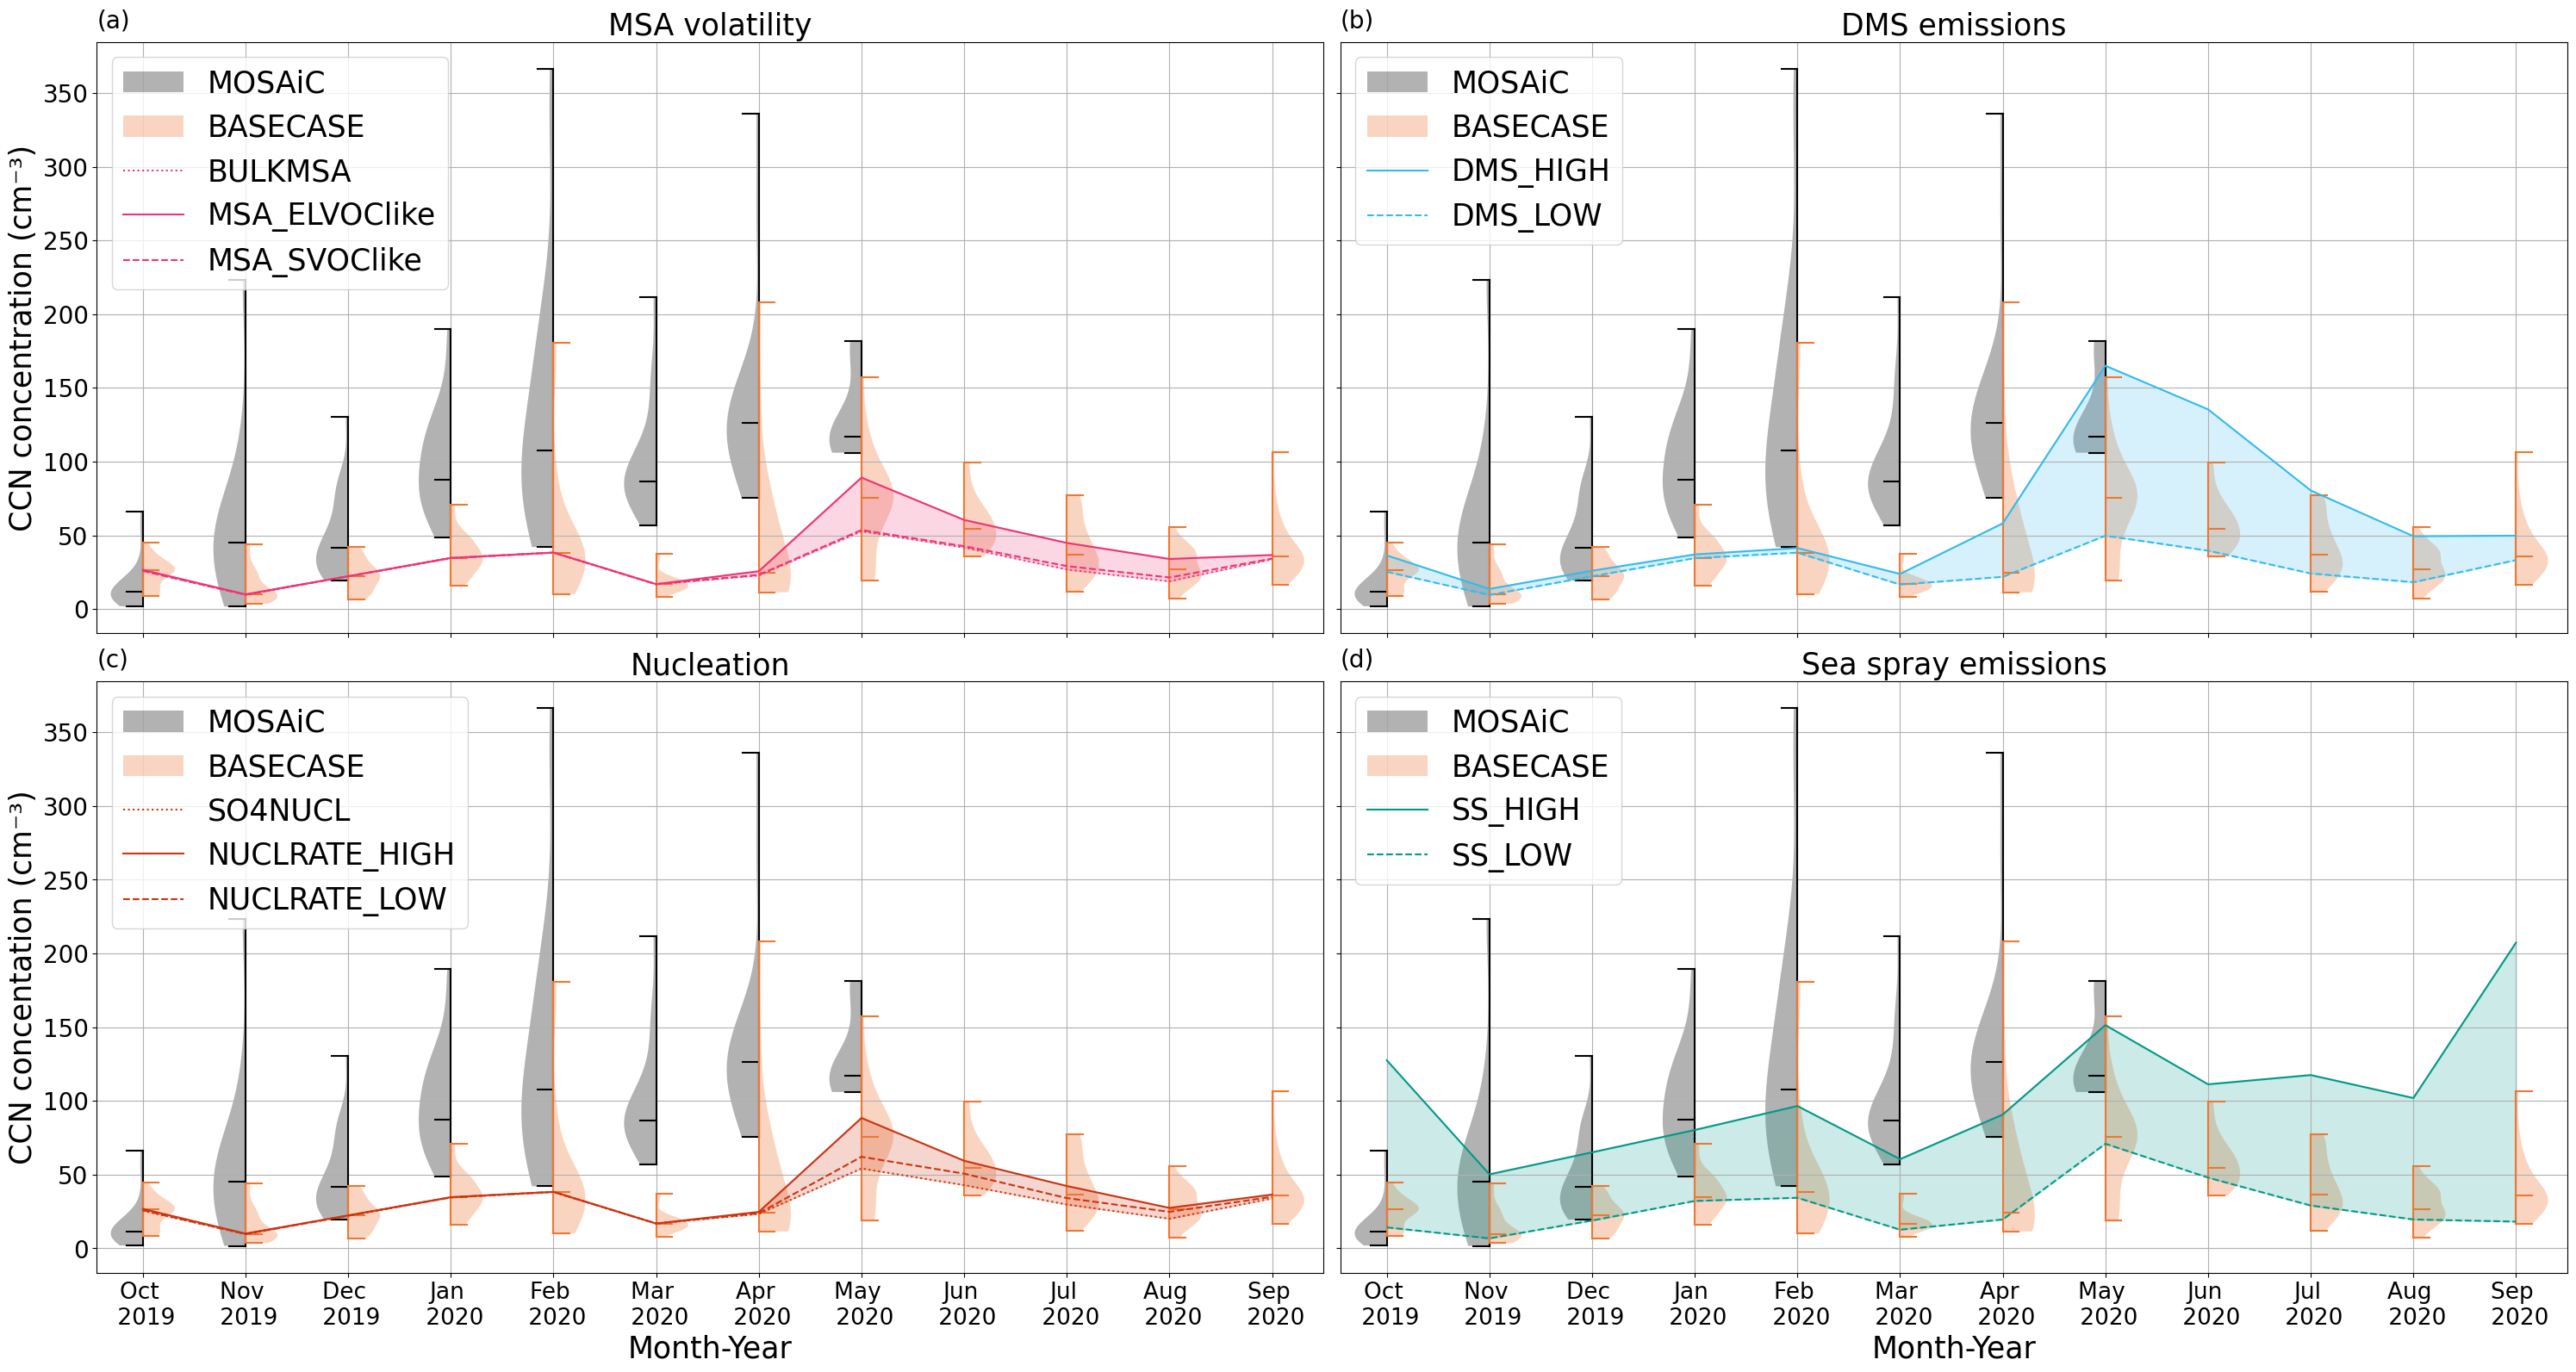

In [16]:
timeline = np.arange(1,25,2)
stair = np.arange(1.0,25.0,4.0)
fig,ax = plt.subplots(2,2,figsize = (30,16),sharex = True,sharey= True)

## MSA volatility
ax[0,0].set_title('MSA volatility',fontsize = 25)
ax[0,0].text(0, 1.025,'(a)',transform=ax[0,0].transAxes,size = 20)
obs = ax[0,0].violinplot(obs_ds,positions = timeline[:8],showmedians=True,side = 'low',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
tm5 = ax[0,0].violinplot(tm5_ds,positions = timeline,showmedians=True,side = 'high',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
for pc in obs['bodies']:
    pc.set_facecolor('k')
for pc in tm5['bodies']:
    pc.set_facecolor(color[0])
obs['cmins'].set_color('k')
obs['cmaxes'].set_color('k')
obs['cbars'].set_color('k')
obs['cmedians'].set_color('k')
tm5['cmins'].set_color(color[0])
tm5['cmaxes'].set_color(color[0])
tm5['cbars'].set_color(color[0])
tm5['cmedians'].set_color(color[0])
obs['bodies'][0].set_label('MOSAiC')
tm5['bodies'][0].set_label('BASECASE')
bx2 = ax[0,0].plot(timeline,bulkmsa_ds['CCN0.20'], color = color[3],linestyle = 'dotted',label = 'BULKMSA')
bx6 = ax[0,0].plot(timeline,msaelvoc_ds['CCN0.20'],color = color[3],label = 'MSA_ELVOClike')
bx7 = ax[0,0].plot(timeline,msasvoc_ds['CCN0.20'],color = color[3],linestyle = '--',label = 'MSA_SVOClike')
#print(np.array([bulkmsa_ds['CCN0.20'],msaelvoc_ds['CCN0.20'],msasvoc_ds['CCN0.20']]).min(axis = 0))
shades = ax[0,0].fill_between(timeline,np.array([bulkmsa_ds['CCN0.20'],msaelvoc_ds['CCN0.20'],msasvoc_ds['CCN0.20']]).min(axis = 0),np.array([bulkmsa_ds['CCN0.20'],msaelvoc_ds['CCN0.20'],msasvoc_ds['CCN0.20']]).max(axis = 0),color = color[3],alpha = 0.2)


ax[0,0].set_xticks(ticks = timeline,labels = [ '10-2019', '11-2019', '12-2019', '01-2020', '02-2020', '03-2020', '04-2020', '05-2020', '06-2020', '07-2020', '08-2020', '09-2020'],fontsize = 25)
#for i in range(1,25,4):
#    plt.axvspan(i-1,i+1,color = '0.2', alpha=0.1, lw=0)
ax[0,0].legend(loc = 'upper left',fontsize = 25)
#ax[0,0].set_xlabel('Month-Year',fontsize = 25)
ax[0,0].set_ylabel('CCN concentration (cm⁻³)',fontsize = 25)
ax[0,0].tick_params(axis = 'y',labelsize = 20)
ax[0,0].set_xlim(0.1,24)
#ax[0,0].set_ylim(0,2000)
## DMS emissions
ax[0,1].set_title('DMS emissions',fontsize = 25)
ax[0,1].text(0, 1.025,'(b)',transform=ax[0,1].transAxes,size = 20)
obs = ax[0,1].violinplot(obs_ds,positions = timeline[:8],showmedians=True,side = 'low',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
tm5 = ax[0,1].violinplot(tm5_ds,positions = timeline,showmedians=True,side = 'high',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
for pc in obs['bodies']:
    pc.set_facecolor('k')
for pc in tm5['bodies']:
    pc.set_facecolor(color[0])
obs['cmins'].set_color('k')
obs['cmaxes'].set_color('k')
obs['cbars'].set_color('k')
obs['cmedians'].set_color('k')
tm5['cmins'].set_color(color[0])
tm5['cmaxes'].set_color(color[0])
tm5['cbars'].set_color(color[0])
tm5['cmedians'].set_color(color[0])
obs['bodies'][0].set_label('MOSAiC')
tm5['bodies'][0].set_label('BASECASE')
bx4 = ax[0,1].plot(timeline,dmshigh_ds['CCN0.20'],color = color[2],label = 'DMS_HIGH')
bx5 = ax[0,1].plot(timeline,dmslow_ds['CCN0.20'],color = color[2],linestyle = '--',label = 'DMS_LOW')
ax[0,1].fill_between(timeline,np.array([dmshigh_ds['CCN0.20'],dmslow_ds['CCN0.20']]).min(axis = 0), np.array([dmshigh_ds['CCN0.20'],dmslow_ds['CCN0.20']]).max(axis = 0),color = color[2],alpha = 0.2)
ax[0,1].set_xticks(ticks = timeline,labels = [ '10-2019', '11-2019', '12-2019', '01-2020', '02-2020', '03-2020', '04-2020', '05-2020', '06-2020', '07-2020', '08-2020', '09-2020'],fontsize = 25)
#for i in range(1,25,4):
#    plt.axvspan(i-1,i+1,color = '0.2', alpha=0.1, lw=0)
ax[0,1].legend(loc = 'upper left',fontsize = 25)
#ax[0,1].set_xlabel('Month-Year',fontsize = 25)
#ax[0,1].set_ylabel('Number Concentration (cm⁻³)',fontsize = 25)
ax[0,1].tick_params(axis = 'y',labelsize = 20)
ax[0,1].set_xlim(0.1,24)

## NUCLEATION RATE

ax[1,0].set_title('Nucleation',fontsize = 25)
ax[1,0].text(0, 1.025,'(c)',transform=ax[1,0].transAxes,size = 20)
obs = ax[1,0].violinplot(obs_ds,positions = timeline[:8],showmedians=True,side = 'low',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
tm5 = ax[1,0].violinplot(tm5_ds,positions = timeline,showmedians=True,side = 'high',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
for pc in obs['bodies']:
    pc.set_facecolor('k')
for pc in tm5['bodies']:
    pc.set_facecolor(color[0])
obs['cmins'].set_color('k')
obs['cmaxes'].set_color('k')
obs['cbars'].set_color('k')
obs['cmedians'].set_color('k')
tm5['cmins'].set_color(color[0])
tm5['cmaxes'].set_color(color[0])
tm5['cbars'].set_color(color[0])
tm5['cmedians'].set_color(color[0])
obs['bodies'][0].set_label('MOSAiC')
tm5['bodies'][0].set_label('BASECASE')
bx3 = ax[1,0].plot(timeline,basecase_nonucl_ds['CCN0.20'],color = color[4],label = 'SO4NUCL',linestyle = 'dotted')
bx4 = ax[1,0].plot(timeline,nuclhigh_ds['CCN0.20'],color = color[4],label = 'NUCLRATE_HIGH')
bx5 = ax[1,0].plot(timeline,nucllow_ds['CCN0.20'],color = color[4],linestyle = '--',label = 'NUCLRATE_LOW')
ax[1,0].fill_between(timeline,np.array([nuclhigh_ds['CCN0.20'],nucllow_ds['CCN0.20'],basecase_nonucl_ds['CCN0.20']]).min(axis = 0), np.array([nuclhigh_ds['CCN0.20'],nucllow_ds['CCN0.20'],basecase_nonucl_ds['CCN0.20']]).max(axis = 0),color = color[4],alpha = 0.2)
ax[1,0].set_xticks(ticks = timeline,labels = [ '10-2019', '11-2019', '12-2019', '01-2020', '02-2020', '03-2020', '04-2020', '05-2020', '06-2020', '07-2020', '08-2020', '09-2020'],fontsize = 19)
#for i in range(1,25,4):
#    plt.axvspan(i-1,i+1,color = '0.2', alpha=0.1, lw=0)
ax[1,0].legend(loc = 'upper left',fontsize = 25)
ax[1,0].set_xlabel('Month-Year',fontsize = 25)
ax[1,0].tick_params(axis = 'y',labelsize = 20)
ax[1,0].set_ylabel('CCN concentation (cm⁻³)',fontsize = 25)
ax[1,0].set_xlim(0.1,24)

## SEA SALT EMISSIONS
ax[1,1].set_title('Sea spray emissions', fontsize = 25)
ax[1,1].text(0, 1.025,'(d)',transform=ax[1,1].transAxes,size = 20)
obs = ax[1,1].violinplot(obs_ds,positions = timeline[:8],showmedians=True,side = 'low',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
tm5 = ax[1,1].violinplot(tm5_ds,positions = timeline,showmedians=True,side = 'high',widths = 1.25)#,quantiles=[[0.25,0.75] for i in range(12)])
for pc in obs['bodies']:
    pc.set_facecolor('k')
for pc in tm5['bodies']:
    pc.set_facecolor(color[0])
obs['cmins'].set_color('k')
obs['cmaxes'].set_color('k')
obs['cbars'].set_color('k')
obs['cmedians'].set_color('k')
tm5['cmins'].set_color(color[0])
tm5['cmaxes'].set_color(color[0])
tm5['cbars'].set_color(color[0])
tm5['cmedians'].set_color(color[0])
obs['bodies'][0].set_label('MOSAiC')
tm5['bodies'][0].set_label('BASECASE')
bx10 = ax[1,1].plot(timeline,sshigh_ds['CCN0.20'],color = color[5],label ='SS_HIGH')
bx11 = ax[1,1].plot(timeline,sslow_ds['CCN0.20'],color = color[5],linestyle = '--',label ='SS_LOW')
ax[1,1].fill_between(timeline,np.array([sshigh_ds['CCN0.20'],sslow_ds['CCN0.20']]).min(axis = 0), np.array([sshigh_ds['CCN0.20'],sslow_ds['CCN0.20']]).max(axis = 0),color = color[5],alpha = 0.2)
ax[1,1].set_xticks(ticks = timeline,labels = [ 'Oct \n 2019', 'Nov \n 2019', 'Dec \n 2019', 'Jan \n 2020', 'Feb \n 2020', 'Mar \n 2020', 'Apr \n 2020', 'May \n 2020', 'Jun \n 2020', 'Jul \n 2020', 'Aug \n 2020', 'Sep \n 2020'],fontsize = 19)
#    plt.axvspan(i-1,i+1,color = '0.2', alpha=0.1, lw=0)
ax[1,1].legend(loc = 'upper left',fontsize = 25)
ax[1,1].set_xlabel('Month-Year',fontsize = 25)
#ax[1,1].set_ylabel('Number Concentration (cm⁻³)',fontsize = 25)
ax[1,1].set_xlim(0.1,24)

'''
bx2 = ax.plot(timeline,bulkmsa_ds['CCN0.20'], color = color[1],label = 'BULKMSA')
bx3 = ax.plot(timeline,basecase_nonucl_ds['CCN0.20'],color = color[1],label = 'SO4NUCL',linestyle = '--')
bx4 = ax.plot(timeline,dmshigh_ds['CCN0.20'],color = color[2],label = 'DMS_HIGH')
bx5 = ax.plot(timeline,dmslow_ds['CCN0.20'],color = color[2],linestyle = '--',label = 'DMS_LOW')
bx6 = ax.plot(timeline,msaelvoc_ds['CCN0.20'],color = color[3],label = 'MSA_ELVOClike')
bx7 = ax.plot(timeline,msasvoc_ds['CCN0.20'],color = color[3],linestyle = '--',label = 'MSA_SVOClike')
bx8 = ax.plot(timeline,nuclhigh_ds['CCN0.20'],color = color[4],label = 'NUCL_HIGH')
bx9 = ax.plot(timeline,nucllow_ds['CCN0.20'],color = color[4],linestyle='--',label = 'NUCL_LOW')
bx10 = ax.plot(timeline,sshigh_ds['CCN0.20'],color = color[5],label ='SS_HIGH')
bx11 = ax.plot(timeline,sslow_ds['CCN0.20'],color = color[5],linestyle = '--',label ='SS_LOW')
'''
plt.tight_layout()
for i in range(2):
    for j in range(2):
        ax[i,j].grid()
#plt.show()

#ax.set_ylim(top= 24.25)
#ax.set_yscale('log')
#print(bx1)
plt.savefig('../figures/ccn0.20_monthlyavg_tiles1.png',dpi = 300)